# Generalized Entropy Index and Theil Index I, Theil Index II

Generalized Entropy Index is used to measure an income inequality in a population. This index uses continuous data like income and population size, and it won't work well with ordinal data. It has multiple properties that make it very handy for analysis, but the most interesting is **decomposability**. The overall index value can be computed from the sum of GE indices within the compared groups. For example, `GE(country) = GE(region_a) + ... + GE(region_z)`.

**Note 1**: this index shouldn't be used with ordinal variables!

## Formulas

There are three formulas, that's why there are three functions in the notebook title. Which one is used depends on the $\alpha$ parameter, that could be any value, but when it is 1 or 0 then we are dealing with First Theil Measure or Second Theil Measure.

The $\alpha$ parameter controls the entropy index.

- $\alpha < 0$ - index is more sensitive to the existence of observations with a small intensity (e.g. very low incomes).
- $\alpha > 1$ - makes it more sensitive to the existence of large outliers (e.g. extremely high incomes).
- $\alpha = 0$ - it calculates Theil Second Measure - index is more sensitive to the lower tail
- $\alpha = 1$ - it calculates Theil First Measure - index is more sensitive to the upper tail

1. $\alpha = 1$ : Theil First Measure

$$T_{T}=\frac{1}{N}\sum^{N}_{i=1}{\frac{x_{i}}{\mu}ln(\frac{x_{i}}{\mu})}$$

2. $\alpha = 0$ : Theil Second Measure

$$T_{L}=\frac{1}{N}\sum^{N}_{i=1}{ln(\frac{\mu}{x_{i})}$$

3. $\alpha \neq 0, 1$

$$GE=\frac{1}{N \alpha (\alpha - 1)}\sum^{N}_{i=1}$$

We will use four different values of $\alpha$ - `{-1, 0, 1, 2}` and see how the index behaves.

## Bibliography

Foster, J., Shneyerov, A. A general class of additively decomposable inequality measures. Economic Theory 14, 89–111 (1999). https://doi.org/10.1007/s001990050283


## World Bank Datasets

1. SP.POP.TOTL: https://data.worldbank.org/indicator/SP.POP.TOTL - World Population Prospects, United Nations ( UN ), uri: population.un.org/wpp, publisher: UN Population Division; Statistical databases and publications from national statistical offices, National Statistical Offices, uri: unstats.un.org/home/nso_sites, publisher: National Statistical Offices; Eurostat: Demographic Statistics, Eurostat ( ESTAT ), uri: ec.europa.eu/eurostat/data/database?node_code=earn_ses_monthly, publisher: Eurostat; Population and Vital Statistics Report ( various years ), United Nations ( UN ), uri: unstats.un.org, publisher: UN Statistics Division
License : CC BY-4.0
2. NY.GDP.PCAP.CD: https://data.worldbank.org/indicator/NY.GDP.PCAP.CD - Country official statistics, National Statistical Organizations and/or Central Banks; National Accounts data files, Organisation for Economic Co-operation and Development ( OECD ); Staff estimates, World Bank ( WB )
License : CC BY-4.0

Both datasets are transformed, we pick only year 2024 and drop all countries where population or GDP were not reported. Full preprocessing notebook is stored in `world-bank-data/preprocess-data.ipynb`.

In [1]:
# Imports

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from surveypie.entropy_index import entropy_index

# Data loading and preparation

In [2]:
ds = pd.read_csv('world-bank-data/gdp-pop-2024-world-bank.csv')
ds.head()

,Country Name,Country Code,GDP-2024,Pop-2024
0,Aruba,ABW,39498.594129,107995.0
1,Africa Eastern and Southern,AFE,1615.396356,769280888.0
2,Africa Western and Central,AFW,1411.337029,521764076.0
3,Angola,AGO,2665.874448,37885849.0
4,Albania,ALB,11377.775743,2377128.0


### Data exploration

Data shows GDP per capita in US dollars and population for multiple countries. We will check distribution of GDP and distribution of population worldwide.

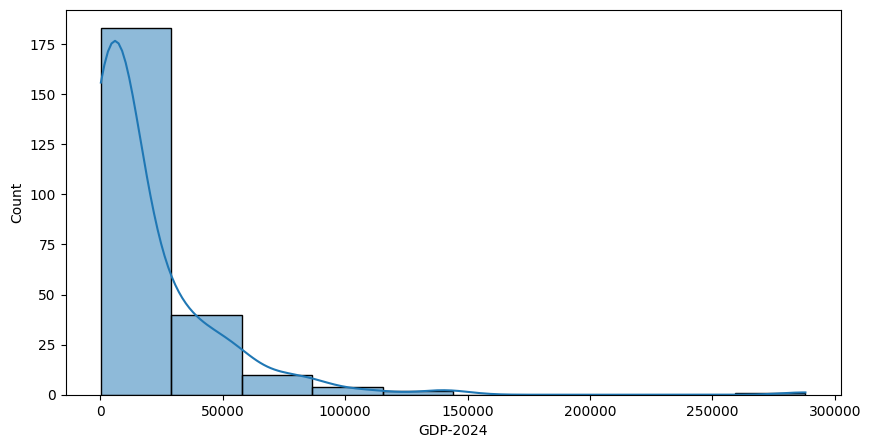

In [3]:
# Plot and visualize input data

plt.figure(figsize=(10,5))
sns.histplot(ds['GDP-2024'], bins=10, kde=True)
plt.show()

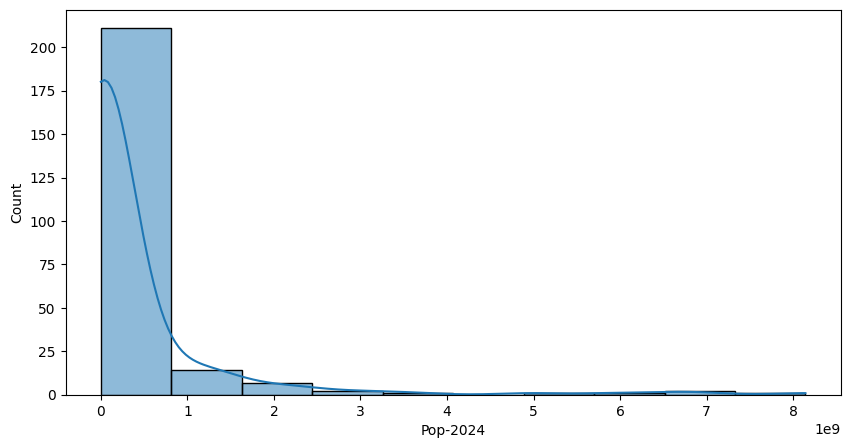

In [4]:
plt.figure(figsize=(10,5))
sns.histplot(ds['Pop-2024'], bins=10, kde=True)
plt.show()

## Entropy Index

Function `entropy_index()` takes two parameters:

- `data`: An array-like structure containing the variable to be analyzed (typically income, wealth, or a similar economic metric).
- `a`: The $\alpha$ parameter, which determines the index's sensitivity to different parts of the distribution. It acts like a lens:
  - `α ≤ 0`: Focuses heavily on the lowest values (the bottom of the distribution).
  - `0 < α < 1`: Shifts focus toward the middle of the distribution.
  - `α ≥ 1`: Focuses heavily on the highest values (the top of the distribution).

The Generalized Entropy index has two special cases where $\alpha$ approaches 0 or 1:
- `α = 0` (Theil's L Index / Mean Log Deviation): Highly sensitive to changes at the lower end of the distribution.
- `α = 1` (Theil's T Index): Equally sensitive to changes across the entire distribution, but often associated with top-heavy inequality.

In [5]:
# Statistics and calculations

alphas = [-1, 0, 0.5, 1, 2]

entropy_indexes = [entropy_index(ds['GDP-2024'].values, alpha) for alpha in alphas]

In [6]:
for en in entropy_indexes:
    print(en)

index=2.4991539954077147 name='Generalized entropy index' n_classes=None a=-1.0
index=1.2826158730987016 name='Generalized entropy index' n_classes=None a=0.0
index=0.7368220451393827 name='Generalized entropy index' n_classes=None a=0.5
index=1.050181240459211 name='Generalized entropy index' n_classes=None a=1.0
index=1.154904844597932 name='Generalized entropy index' n_classes=None a=2.0


## Summary

Entropy Index is easy to control, and we have done that using $\alpha$ parameter. In general, we see that for all cases, GDP per capita is extremely unequal. It is U-shaped, and higher inequality exists when we compare countries with low GDP per capita to others, than when we compare countries with high GDP per capita.

**Index equal to 0 means that there is a perfect equality.**

### $\alpha = -1$

The focus is on the countries with the lowest GDP. Index value is very high, which means, that the difference between the countries with lowest and the highest GDP per capita is extreme.

### $\alpha = 0$

The Second Theil Measure - it also measures the lower bottom of the distribution, and value above 1 clearly shows that inequality between countries is extreme.

### $\alpha = 0.5$

Focuses in the middle part of GDP per capita distribution. It is lower than 1 (means that the middle part is relatively more equal BUT it is still very high inequality).

### $\alpha = 1$

The First Theil Measure. It is proportional to the all available countries. The value larger than 1 means that inequality between datasets is very high.

### $\alpha = 2$

This parameter focuses heavily on the upper tail of the dataset. The value is exceptionally high because global GDP per capita data contains severe high-income outliers. Those outliers are mostly micro-states, financial hubs, and resource-rich nations (like Monaco, Luxembourg, Ireland, and Singapore).

## Changelog

- 2026-06-16 : Szymon Moliński (@SimonMolinsky) : first release